<a href="https://colab.research.google.com/github/IT24100378/ToxicCommentNLPfinal/blob/Remove-Stopwards/Remove_Stopwords.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already
nltk.download('stopwords')

# ---------------- Step 1: Load Dataset ----------------
import csv
df = pd.read_csv("train_tokenized.csv", on_bad_lines='skip', engine='python')



# Show dataset info and first 5 rows
print("\nDataset Info:")
print(df.info())
print("\nFirst 5 Rows:")
print(df.head())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tokens  16000 non-null  object
 1   toxic   16000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 250.1+ KB
None

First 5 Rows:
                                              tokens  toxic
0  ['lighten', 'up', 'francis', 'on', 'same', 'te...      0
1  ['lisa', 'williams', 'is', 'a', 'total', 'frau...      1
2  ['i', 'am', 'david', 'in', 'dc', 'not', 'david...      1
3  ['fuck', 'you', 'fuck', 'you', 'keep', 'blocki...      1
4  ['both', 'entries', 'are', 'on', 'the', 'same'...      0


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rznah\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Shape of dataset: (16000, 2)

First 5 rows:
                                               tokens  toxic
0  ['lighten', 'up', 'francis', 'on', 'same', 'te...      0
1  ['lisa', 'williams', 'is', 'a', 'total', 'frau...      1
2  ['i', 'am', 'david', 'in', 'dc', 'not', 'david...      1
3  ['fuck', 'you', 'fuck', 'you', 'keep', 'blocki...      1
4  ['both', 'entries', 'are', 'on', 'the', 'same'...      0

Missing values:
 tokens    0
toxic     0
dtype: int64

Class distribution:
 toxic
0    8000
1    8000
Name: count, dtype: int64


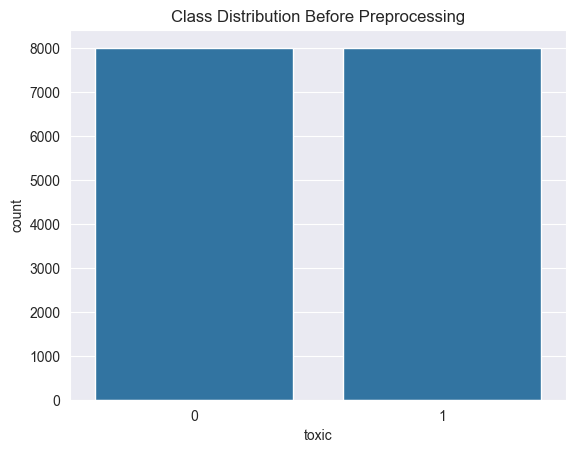

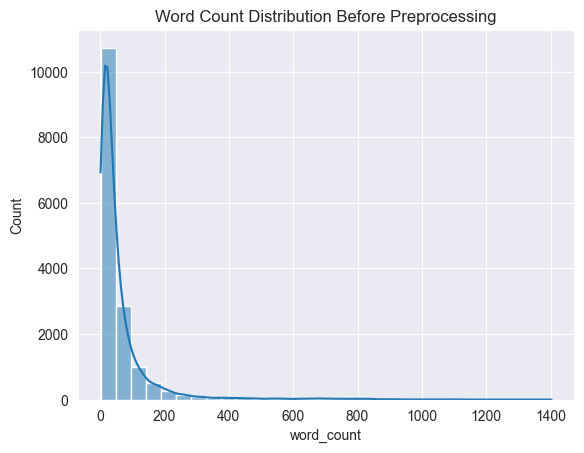

In [2]:
# ---------------- Step 2: EDA Before Preprocessing ----------------
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution:\n", df['toxic'].value_counts())

# Plot toxic distribution
sns.countplot(x='toxic', data=df)
plt.title("Class Distribution Before Preprocessing")
plt.show()

# Word count before preprocessing
df['word_count'] = df['tokens'].apply(lambda x: len(str(x).split()))
sns.histplot(df['word_count'], bins=30, kde=True)
plt.title("Word Count Distribution Before Preprocessing")
plt.show()





In [3]:
# ---------------- Step 3: Stopword Removal ----------------
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = str(text).split()
    filtered_words = [w for w in words if w.lower() not in stop_words]
    return " ".join(filtered_words)

df['tokens'] = df['tokens'].apply(remove_stopwords)


After preprocessing (stopword removal):
                                              tokens  toxic
0  ['lighten', 'up', 'francis', 'on', 'same', 'te...      0
1  ['lisa', 'williams', 'is', 'a', 'total', 'frau...      1
2  ['i', 'am', 'david', 'in', 'dc', 'not', 'david...      1
3  ['fuck', 'you', 'fuck', 'you', 'keep', 'blocki...      1
4  ['both', 'entries', 'are', 'on', 'the', 'same'...      0


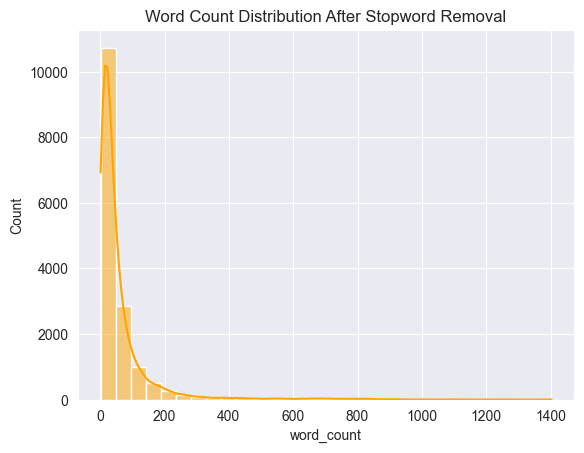

In [5]:
# ---------------- Step 4: EDA After Preprocessing ----------------
print("\nAfter preprocessing (stopword removal):")
df['word_count'] = df['tokens'].apply(lambda x: len(str(x).split()))
print(df[[ 'tokens', 'toxic']].head())

# Plot word count after preprocessing
sns.histplot(df['word_count'], bins=30, kde=True, color="orange")
plt.title("Word Count Distribution After Stopword Removal")
plt.show()

In [6]:
# ---------------- Step 5: Save Final Preprocessed File ----------------
final_df = df[['tokens', 'toxic']]
final_df.to_csv("preprocessed_stopwords_removed.csv", index=False)

print(" Preprocessed file saved as 'preprocessed_stopwords_removed.csv'")

 Preprocessed file saved as 'preprocessed_stopwords_removed.csv'
